In [ ]:
import pandas as pd

df = pd.read_csv('/content/Loan Repayment.csv')

In [ ]:
display(df.head())

,customer_id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,Repaid
0,1,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,0.59,3,Yes
1,2,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0.10,2,No
2,3,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,0.57,3,Yes
3,4,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,0.53,2,Yes
4,5,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,0.55,4,Yes


In [ ]:
df.info()
display(df.describe())
display(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 32581 non-null  int64  
 1   person_age                  32581 non-null  int64  
 2   person_income               32581 non-null  int64  
 3   person_home_ownership       32581 non-null  object 
 4   person_emp_length           31686 non-null  float64
 5   loan_intent                 32581 non-null  object 
 6   loan_grade                  32581 non-null  object 
 7   loan_amnt                   32581 non-null  int64  
 8   loan_int_rate               29465 non-null  float64
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_cred_hist_length  32581 non-null  int64  
 11  Repaid                      32581 non-null  object 
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


,customer_id,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000
mean,16291.000000,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.170203,5.804211
std,9405.468897,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.106782,4.055001
min,1.000000,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000
25%,8146.000000,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.090000,3.000000
50%,16291.000000,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.150000,4.000000
75%,24436.000000,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.230000,8.000000
max,32581.000000,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,0.830000,30.000000


,0
customer_id,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,3116
loan_percent_income,0


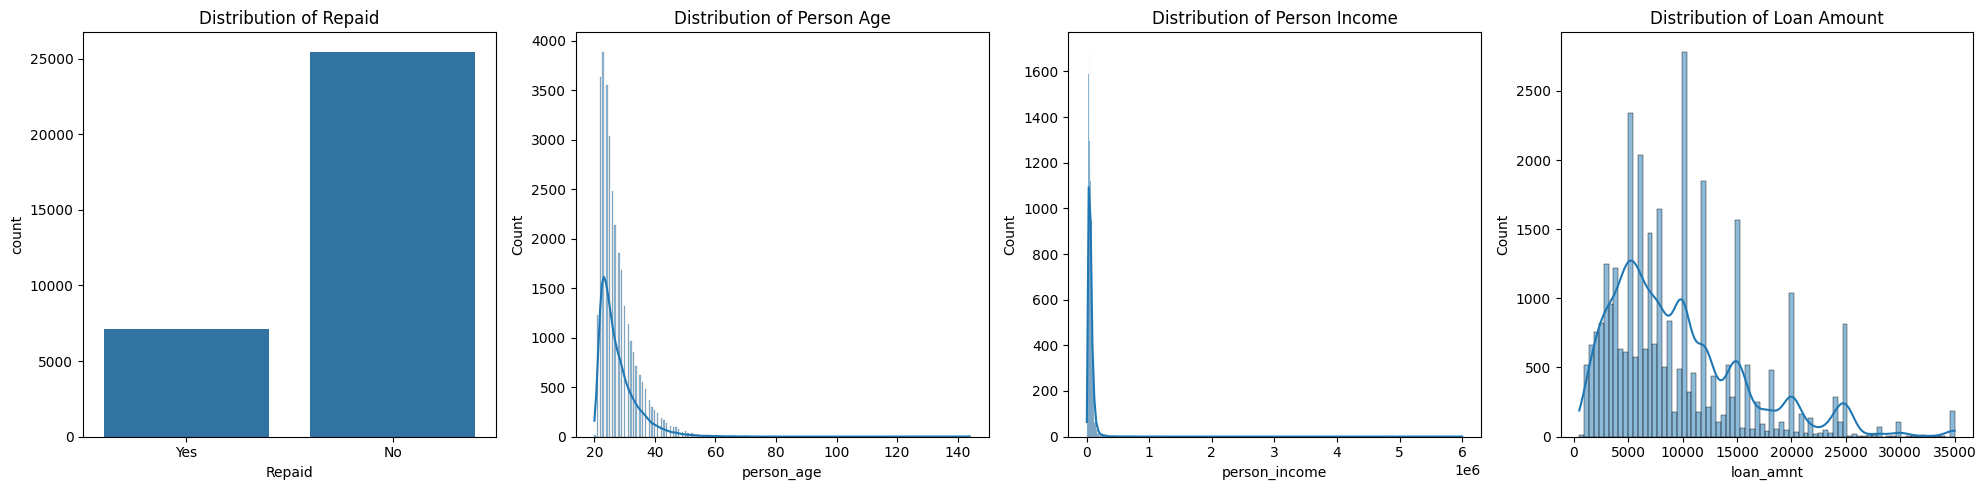

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

sns.countplot(x='Repaid', data=df, ax=axes[0])
axes[0].set_title('Distribution of Repaid')

sns.histplot(df['person_age'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Person Age')

sns.histplot(df['person_income'], kde=True, ax=axes[2])
axes[2].set_title('Distribution of Person Income')

sns.histplot(df['loan_amnt'], kde=True, ax=axes[3])
axes[3].set_title('Distribution of Loan Amount')

plt.tight_layout()
plt.show()

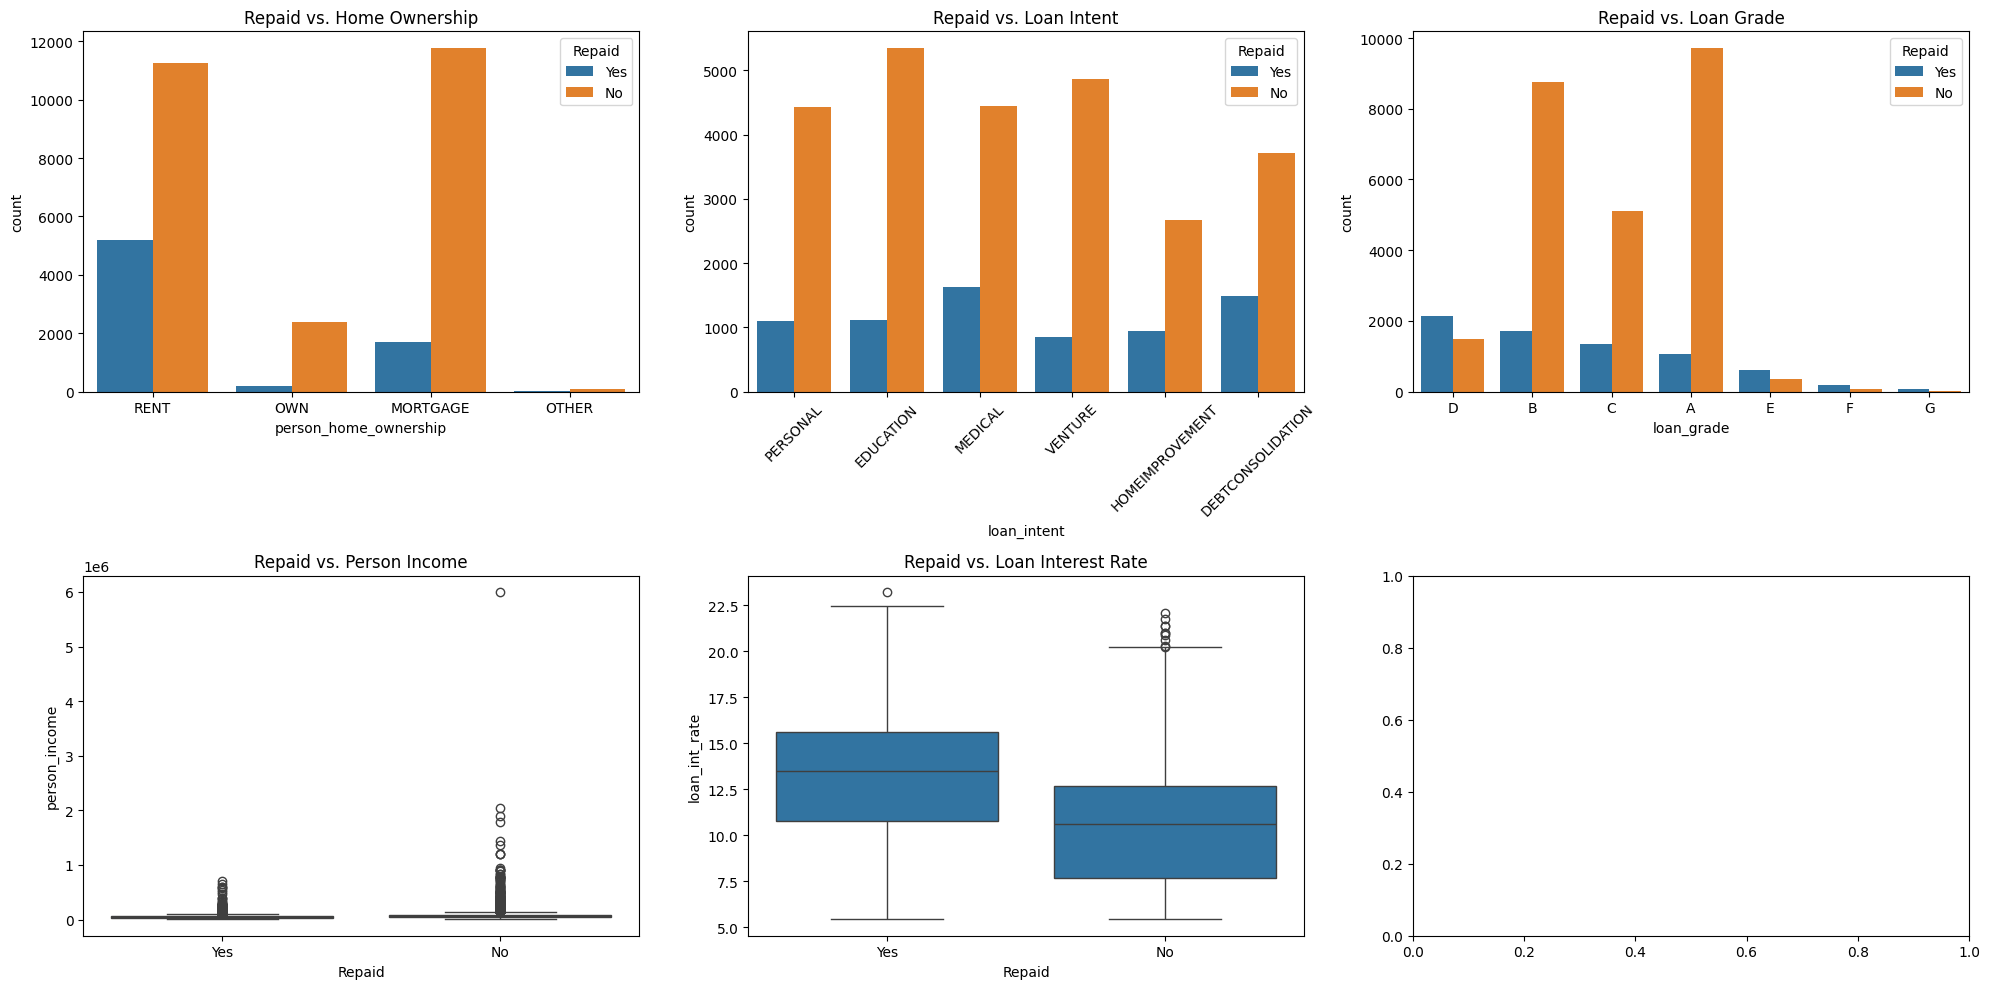

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

sns.countplot(x='person_home_ownership', hue='Repaid', data=df, ax=axes[0, 0])
axes[0, 0].set_title('Repaid vs. Home Ownership')

sns.countplot(x='loan_intent', hue='Repaid', data=df, ax=axes[0, 1])
axes[0, 1].set_title('Repaid vs. Loan Intent')
axes[0, 1].tick_params(axis='x', rotation=45)

sns.countplot(x='loan_grade', hue='Repaid', data=df, ax=axes[0, 2])
axes[0, 2].set_title('Repaid vs. Loan Grade')

sns.boxplot(x='Repaid', y='person_income', data=df, ax=axes[1, 0])
axes[1, 0].set_title('Repaid vs. Person Income')

sns.boxplot(x='Repaid', y='loan_int_rate', data=df, ax=axes[1, 1])
axes[1, 1].set_title('Repaid vs. Loan Interest Rate')

plt.tight_layout()
plt.show()

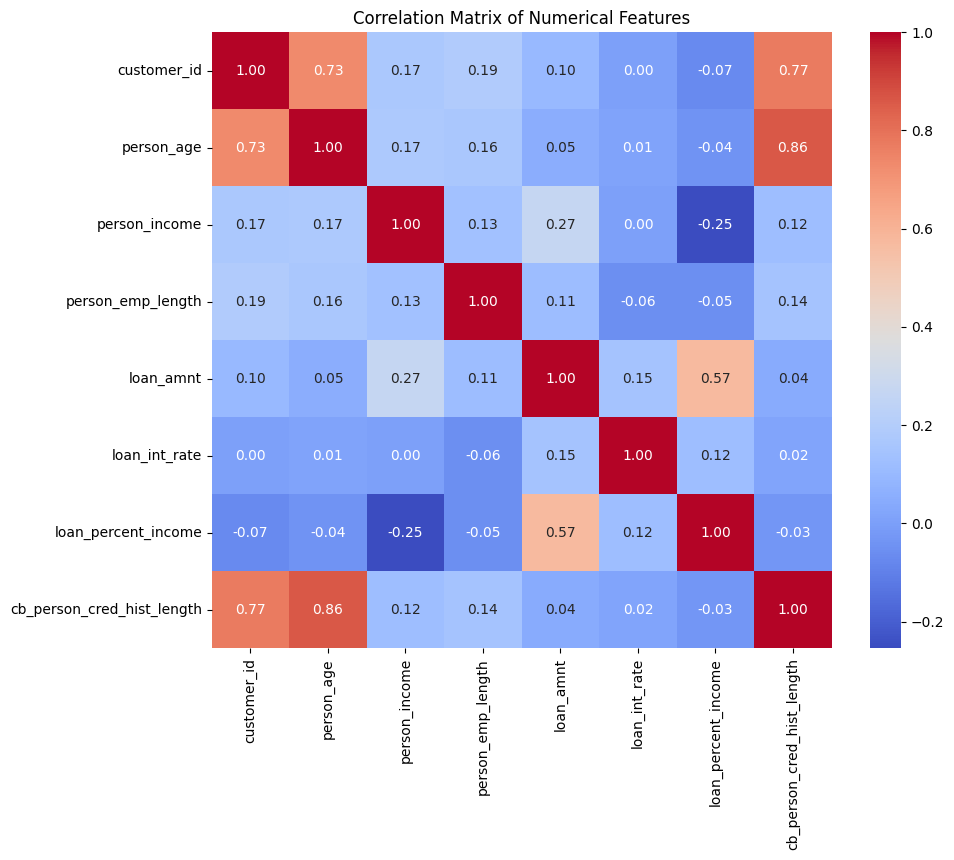

In [ ]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
correlation_matrix = df[numerical_cols].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [ ]:
df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)
df['loan_int_rate'].fillna(df['loan_int_rate'].median(), inplace=True)
display(df.isnull().sum())

/tmp/ipython-input-703457414.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)
/tmp/ipython-input-703457414.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(v

,0
customer_id,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_percent_income,0


In [ ]:
df = pd.get_dummies(df, columns=['person_home_ownership', 'loan_intent', 'loan_grade'], drop_first=True)
df['Repaid'] = df['Repaid'].map({'Yes': 1, 'No': 0})
display(df.head())

,customer_id,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,Repaid,person_home_ownership_OTHER,...,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G
0,1,22,59000,123.0,35000,16.02,0.59,3,1,False,...,False,False,True,False,False,False,True,False,False,False
1,2,21,9600,5.0,1000,11.14,0.10,2,0,False,...,False,False,False,False,True,False,False,False,False,False
2,3,25,9600,1.0,5500,12.87,0.57,3,1,False,...,False,True,False,False,False,True,False,False,False,False
3,4,23,65500,4.0,35000,15.23,0.53,2,1,False,...,False,True,False,False,False,True,False,False,False,False
4,5,24,54400,8.0,35000,14.27,0.55,4,1,False,...,False,True,False,False,False,True,False,False,False,False


In [ ]:
from sklearn.preprocessing import StandardScaler

numerical_cols = ['person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])
display(df.head())

,customer_id,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,Repaid,person_home_ownership_OTHER,...,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G
0,1,-0.903374,-0.114143,28.926614,4.019404,1.625921,3.931411,-0.691554,1,False,...,False,False,True,False,False,False,True,False,False,False
1,2,-1.060904,-0.911147,0.056763,-1.358650,0.042310,-0.657458,-0.938167,0,False,...,False,False,False,False,True,False,False,False,False,False
2,3,-0.430783,-0.911147,-0.921876,-0.646849,0.603713,3.744110,-0.691554,1,False,...,False,True,False,False,False,True,False,False,False,False
3,4,-0.745843,-0.009274,-0.187897,4.019404,1.369558,3.369508,-0.938167,1,False,...,False,True,False,False,False,True,False,False,False,False
4,5,-0.588313,-0.188358,0.790742,4.019404,1.058028,3.556809,-0.444942,1,False,...,False,True,False,False,False,True,False,False,False,False


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Repaid', axis=1)
y = df['Repaid']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (24435, 22)
X_test shape: (8146, 22)
y_train shape: (24435,)
y_test shape: (8146,)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.svm import SVC

svm_model = SVC(random_state=42)
svm_model.fit(X_train, y_train)

SVC(random_state=42)

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Evaluate Random Forest model
rf_predictions = rf_model.predict(X_test)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)
rf_accuracy = accuracy_score(y_test, rf_predictions)

print("Random Forest Model Metrics:")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")
print(f"F1 Score: {rf_f1:.4f}")
print(f"Accuracy: {rf_accuracy:.4f}")
print("-" * 30)

# Evaluate SVM model
svm_predictions = svm_model.predict(X_test)
svm_precision = precision_score(y_test, svm_predictions)
svm_recall = recall_score(y_test, svm_predictions)
svm_f1 = f1_score(y_test, svm_predictions)
svm_accuracy = accuracy_score(y_test, svm_predictions)

print("SVM Model Metrics:")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall: {svm_recall:.4f}")
print(f"F1 Score: {svm_f1:.4f}")
print(f"Accuracy: {svm_accuracy:.4f}")

Random Forest Model Metrics:
Precision: 0.9507
Recall: 0.7276
F1 Score: 0.8244
Accuracy: 0.9324
------------------------------
SVM Model Metrics:
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
Accuracy: 0.7819


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best F1 score found: ", grid_search.best_score_)

best_rf_model = grid_search.best_estimator_